**FAKE NEWS DETECTOR**

- Siddhi Vaidya
- Shruti Thakur

**PROBLEM STATEMENT**:
The objective of this work is to use Machine learning to predict if the news is True or Fake.

**INTRODUCTION**:
In our modern era where the internet is ubiquitous, everyone relies on various online resources for news. Along with the increase in the use of social media platforms like Facebook, Twitter, etc. news spread rapidly among millions of users within a very short span of time. The spread of fake news has far-
reaching consequences like the creation of biased opinions to sway election outcomes for the benefit of certain candidates. Moreover, spammers use appealing news headlines to generate revenue using advertisements via
click-baits. In this paper, we aim to perform binary classification of various news articles available online with the help of concepts pertaining to Artificial Intelligence, Natural Language Processing and Machine Learning.
We aim to provide the user with the ability to classify the news as fake or real and also check the authenticity of
the website publishing the news.

**Dataset Information:**
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

**AIM:**
The objective of this work is to use Machine learning to predict if the news is True or Fake.

In [ ]:
import pandas as pd

news = pd.read_csv("fake_and_real_news.csv")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn import feature_extraction, linear_model, model_selection, preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [ ]:
news.shape

(9900, 2)

DATA CLEANING AND PREPARATION

In [ ]:
news.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [ ]:
#download dataset

In [ ]:
#convert to lowercase
news['Text']=news['Text'].apply(lambda x:x.lower())
news.head()

,Text,label
0,top trump surrogate brutally stabs him in the...,Fake
1,u.s. conservative leader optimistic of common ...,Real
2,"trump proposes u.s. tax overhaul, stirs concer...",Real
3,court forces ohio to allow millions of illega...,Fake
4,democrats say trump agrees to work on immigrat...,Real


In [ ]:
#removing punctuation
import string

def punctuation_removal(text):
  all_list = [char for char in text if char not in string.punctuation]
  clean_str = ''.join(all_list)
  return clean_str

news['Text'] = news['Text'].apply(punctuation_removal)
news.head()

,Text,label
0,top trump surrogate brutally stabs him in the...,Fake
1,us conservative leader optimistic of common gr...,Real
2,trump proposes us tax overhaul stirs concerns ...,Real
3,court forces ohio to allow millions of illega...,Fake
4,democrats say trump agrees to work on immigrat...,Real


In [ ]:
# Removing stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

news['Text'] = news['Text'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


The Natural Language Toolkit (NLTK) is a platform used for building Python programs that work with human
language data for applying in statistical natural language processing (NLP). It contains text processing libraries
for tokenization, parsing, classification, stemming, tagging and semantic reasoning.

STOP WORDS: Stop words are common words like ‘the’, ‘and’, ‘I’, etc. that are very frequent in text, and so
don’t convey insights into the specific topic of a document. We can remove these stop words from the text in a
given corpus to clean up the data, and identify words that are more rare and potentially more relevant to what
we’re interested in.
Text may contain stop words like ‘the’, ‘is’, ‘are’. Stop words can be filtered from the text to be processed.
There is no universal list of stop words in nlp research, however the nltk module contains a list of stop words.

In [ ]:
news.head()
#data after removing stopwords

,Text,label
0,top trump surrogate brutally stabs back ‘he’s ...,Fake
1,us conservative leader optimistic common groun...,Real
2,trump proposes us tax overhaul stirs concerns ...,Real
3,court forces ohio allow millions illegally pur...,Fake
4,democrats say trump agrees work immigration bi...,Real


BASIC DATA EXPLORATION

label
Fake    5000
Real    4900
Name: Text, dtype: int64


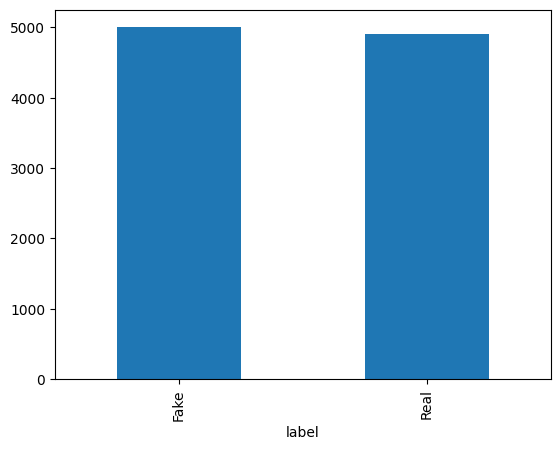

In [ ]:
# How many fake and real articles?
print(news.groupby(['label'])['Text'].count())
news.groupby(['label'])['Text'].count().plot(kind="bar")
plt.show()

In [ ]:
from nltk import tokenize

token_space = tokenize.WhitespaceTokenizer()

def counter(data, column_text, quantity):
    all_words = ' '.join([text for text in data[column_text]])
    token_phrase = token_space.tokenize(all_words)
    frequency = nltk.FreqDist(token_phrase)
    df_frequency = pd.DataFrame({"Word": list(frequency.keys()),
                                 "Frequency": list(frequency.values())})
    df_frequency = df_frequency.nlargest(columns="Frequency", n=quantity)

    plt.figure(figsize=(12, 8))
    ax = sns.barplot(data=df_frequency, x="Word", y="Frequency", color='blue')
    ax.set(ylabel="Count")
    plt.xticks(rotation='vertical')
    plt.title(f"Top {quantity} Most Frequent Words in '{column_text}' Column")
    plt.show()

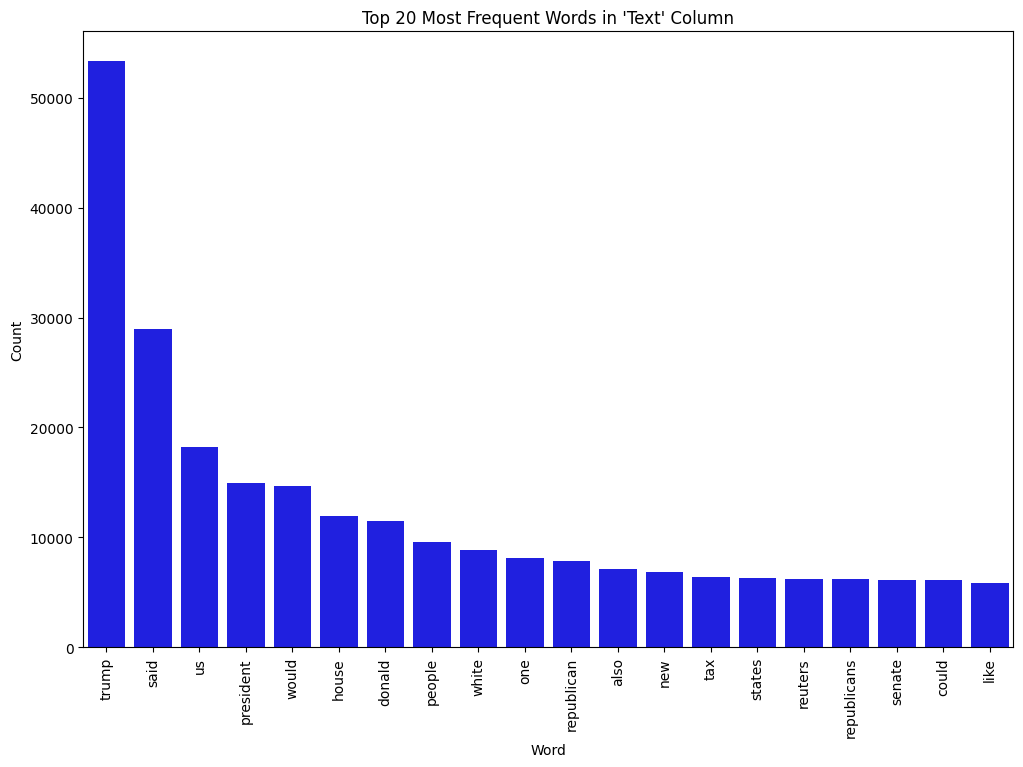

In [ ]:
counter(news, 'Text', 20)

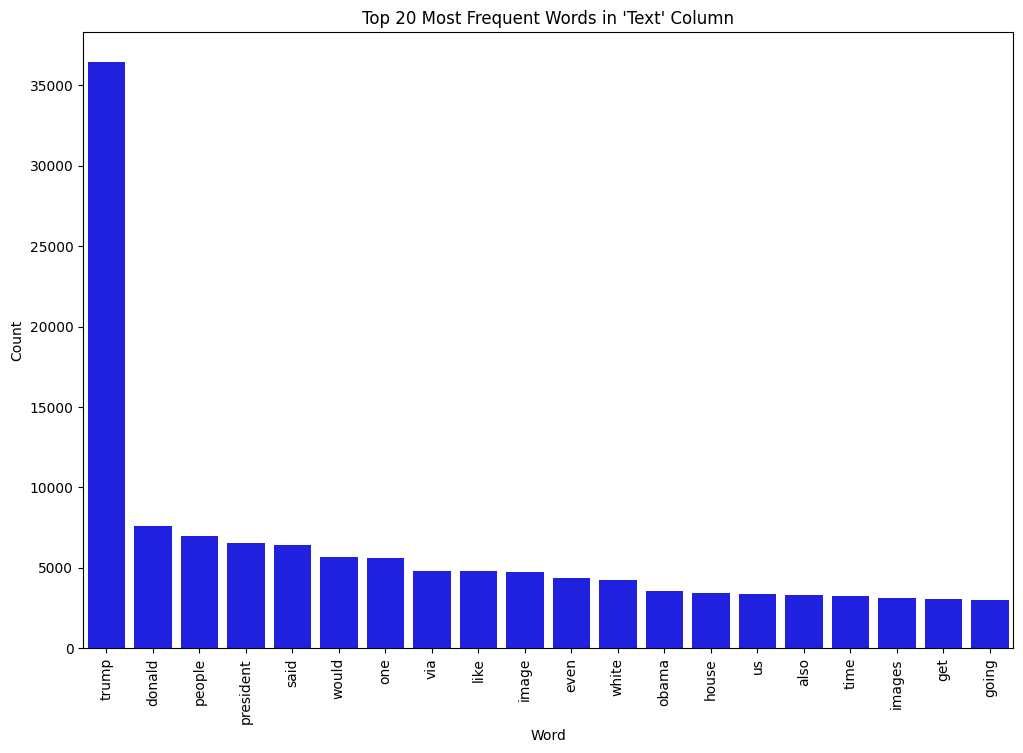

In [ ]:
counter(news[news["label"] == "Fake"], "Text", 20)

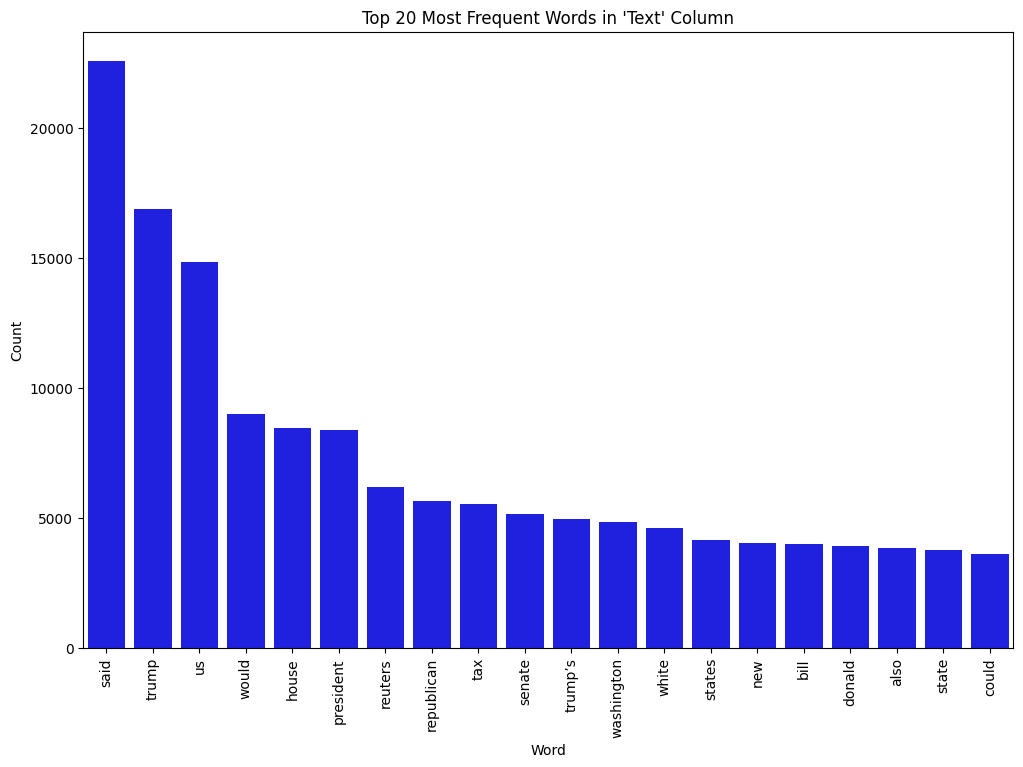

In [ ]:
# Most frequent words in real news
counter(news[news["label"] == "Real"], "Text", 20)

MODELING

In [ ]:
# Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import joblib
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

news['label'] = news['label'].map({'Fake': 0, 'Real': 1})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    news['Text'], news['label'], test_size=0.2, random_state=42, stratify=news['label']
)

print(" Dataset ready for modeling.")
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

 Dataset ready for modeling.
Train size: 7920
Test size: 1980


Test Size is 20%.

random state ensures reproducibility meaning if the code is ran again in the future, the result must remains the same.Meaning the data is split in the same way everytime.

Stratify preserves class ratio in both splits.

In [ ]:
# Helper Function
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], '.2f' if normalize else 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


NAIVE BAYES

In [ ]:
# Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ('vect', CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=8000)),
    ('tfidf', TfidfTransformer()),
    ('model', MultinomialNB())
])

print("Training Naive Bayes...")
nb_model = pipe_nb.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

acc_nb = round(accuracy_score(y_test, y_pred_nb) * 100, 2)
print(f"Naive Bayes Accuracy: {acc_nb}%")



Training Naive Bayes...
Naive Bayes Accuracy: 96.62%


Confusion matrix, without normalization
[[970  30]
 [ 37 943]]

Classification Report (Naive Bayes):

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1000
           1       0.97      0.96      0.97       980

    accuracy                           0.97      1980
   macro avg       0.97      0.97      0.97      1980
weighted avg       0.97      0.97      0.97      1980



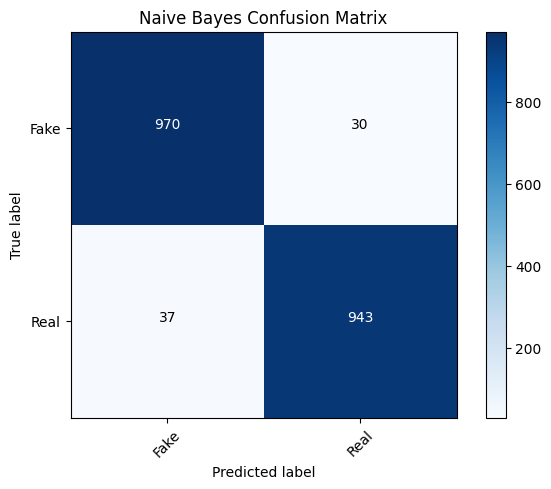

In [ ]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plot_confusion_matrix(cm_nb, classes=['Fake', 'Real'], title='Naive Bayes Confusion Matrix')

print("\nClassification Report (Naive Bayes):\n")
print(classification_report(y_test, y_pred_nb))


In [ ]:
# Save model
#joblib.dump(nb_model, 'news_detector_nb_model.pkl')
print("Saved as news_detector_nb_model.pkl")
#from google.colab import files
#files.download('news_detector_nb_model.pkl')


Saved as news_detector_nb_model.pkl


LOGISTIC REGRESSION




In [ ]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('vect', CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=8000)),
    ('tfidf', TfidfTransformer()),
    ('model', LogisticRegression(max_iter=500, solver='lbfgs', random_state=42))
])

print("Training Logistic Regression...")
lr_model = pipe_lr.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

acc_lr = round(accuracy_score(y_test, y_pred_lr) * 100, 2)
print(f"Logistic Regression Accuracy: {acc_lr}%")


Training Logistic Regression...
Logistic Regression Accuracy: 99.04%


Limited-memory Broyden–Fletcher–Goldfarb–Shanno algorithm

Confusion matrix, without normalization
[[992   8]
 [ 11 969]]

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.99      0.99       980

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



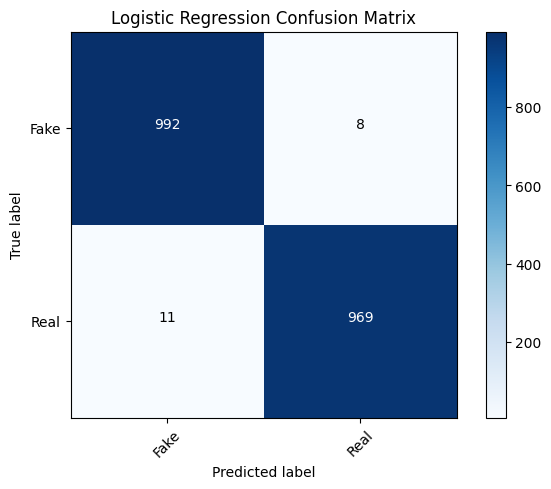

In [ ]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plot_confusion_matrix(cm_lr, classes=['Fake', 'Real'], title='Logistic Regression Confusion Matrix')

print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr))

In [ ]:
# Save model
#joblib.dump(lr_model, 'news_detector_lr_model.pkl')
#print("Saved as news_detector_lr_model.pkl")
#from google.colab import files
#files.download('news_detector_lr_model.pkl')


DECISION TREE

In [ ]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt

print("Training Decision Tree Classifier...")

# Build pipeline with tuned parameters
pipe_dt = Pipeline([
    ('vect', CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=8000)),
    ('tfidf', TfidfTransformer()),
    ('model', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=40,        # limit tree depth to prevent overfitting
        min_samples_split=6, # each split must have at least 6 samples
        min_samples_leaf=3,  # each leaf must have at least 3 samples
        splitter='best',
        random_state=42
    ))
])

# Train
dt_model = pipe_dt.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Accuracy
acc_dt = round(accuracy_score(y_test, y_pred_dt) * 100, 2)
print(f"Decision Tree Accuracy: {acc_dt}%")


Training Decision Tree Classifier...
Decision Tree Accuracy: 99.7%


Confusion matrix, without normalization
[[998   2]
 [  4 976]]

Classification Report (Decision Tree):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00       980

    accuracy                           1.00      1980
   macro avg       1.00      1.00      1.00      1980
weighted avg       1.00      1.00      1.00      1980



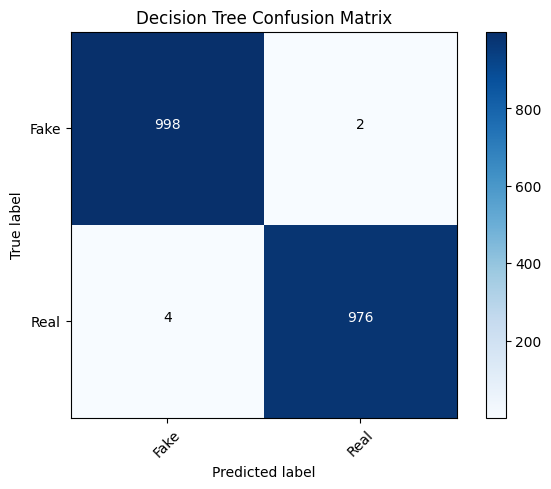

In [ ]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plot_confusion_matrix(cm_dt, classes=['Fake', 'Real'], title='Decision Tree Confusion Matrix')

print("\nClassification Report (Decision Tree):\n")
print(classification_report(y_test, y_pred_dt))



In [ ]:
# Save model
#joblib.dump(dt_model, 'news_detector_dt_model.pkl')
print("Saved as news_detector_dt_model.pkl")

Saved as news_detector_dt_model.pkl


Random Forest

In [ ]:
# RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Classifier...")

pipe_rf = Pipeline([
    ('vect', CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=8000)),
    ('tfidf', TfidfTransformer()),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=50,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model = pipe_rf.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf = round(accuracy_score(y_test, y_pred_rf) * 100, 2)
print(f"Random Forest Accuracy: {acc_rf}%")

Training Random Forest Classifier...
Random Forest Accuracy: 99.95%


Confusion matrix, without normalization
[[1000    0]
 [   1  979]]

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00       980

    accuracy                           1.00      1980
   macro avg       1.00      1.00      1.00      1980
weighted avg       1.00      1.00      1.00      1980



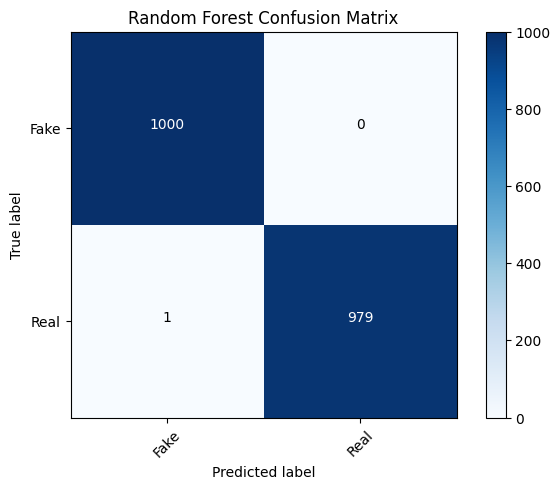

In [ ]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plot_confusion_matrix(cm_rf, classes=['Fake', 'Real'], title='Random Forest Confusion Matrix')

print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))


Linear SVM

In [ ]:
# SVM MODEL (LinearSVC)
from sklearn.svm import LinearSVC

print("Training SVM (LinearSVC)...")

pipe_svm = Pipeline([
    ('vect', CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=8000)),
    ('tfidf', TfidfTransformer()),
    ('model', LinearSVC(C=1.0, max_iter=2000))
])

svm_model = pipe_svm.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

acc_svm = round(accuracy_score(y_test, y_pred_svm) * 100, 2)
print(f"SVM Accuracy: {acc_svm}%")


Training SVM (LinearSVC)...
SVM Accuracy: 99.7%


Confusion matrix, without normalization
[[998   2]
 [  4 976]]

Classification Report (SVM):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00       980

    accuracy                           1.00      1980
   macro avg       1.00      1.00      1.00      1980
weighted avg       1.00      1.00      1.00      1980



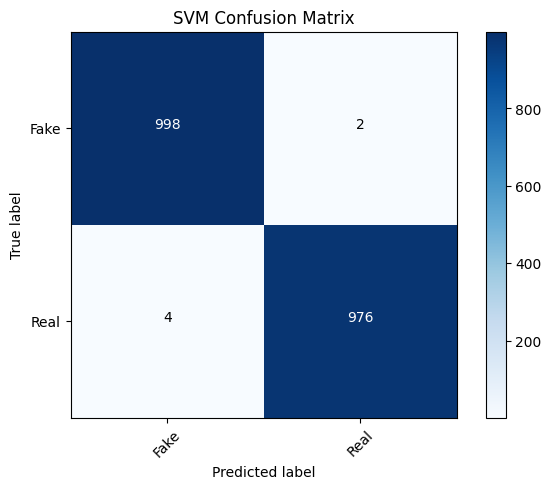

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plot_confusion_matrix(cm_svm, classes=['Fake', 'Real'], title='SVM Confusion Matrix')

print("\nClassification Report (SVM):\n")
print(classification_report(y_test, y_pred_svm))


                     Accuracy
Naive Bayes             96.62
Logistic Regression     99.04
Decision Tree           99.70
Random Forest           99.95
SVM (LinearSVC)         99.70


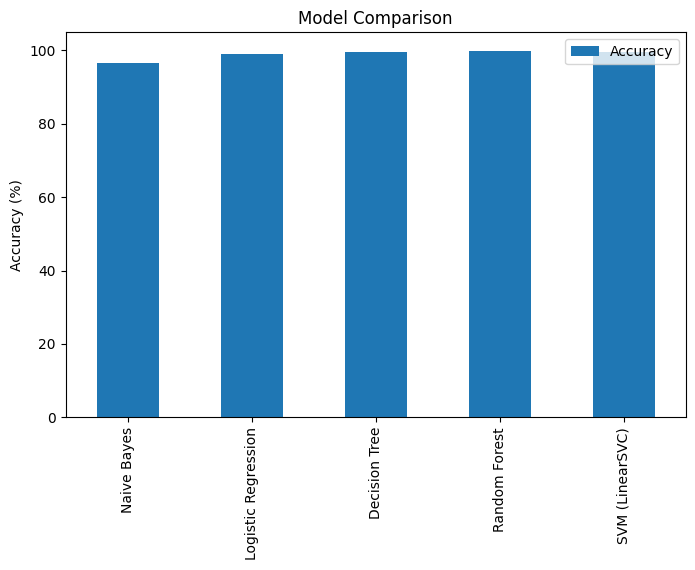

In [ ]:
results = {
    "Naive Bayes": acc_nb,
    "Logistic Regression": acc_lr,
    "Decision Tree": acc_dt,
    "Random Forest": acc_rf,
    "SVM (LinearSVC)": acc_svm,
}

model_acc_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
print(model_acc_df)
model_acc_df.plot(kind='bar', figsize=(8,5))
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.show()

**CONCLUSION**:
In the 21st century, the majority of the tasks are done online. Newspapers that
were earlier preferred as hard-copies are now being substituted by applications
like Facebook, Twitter, and news articles to be read online. Whatsapp’s forwards
are also a major source. The growing problem of fake news only makes things more
complicated and tries to change or hamper the opinion and attitude of people
towards use of digital technology. When a person is deceived by the real news two possible things happen- People start believing that their perceptions about a particular topic are true as assumed. Thus, in order to curb the phenomenon, we have developed our Fake news Detection system that takes input from the user and classifies it to be true or fake. To implement this, various Machine Learning Techniques have to be used. The model is trained using an appropriate dataset and performance evaluation is also done using various performance measures. The best model, i.e. the model with highest accuracy is used to classify the news headlines or articles. The user can check the
news article or keywords online; he can also check the authenticity of the website.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
import transformers

# NLTK veri setlerini indir
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from datasets import Dataset
from transformers import BertTokenizer

In [ ]:
data_dict = {'Text': news['Text'], 'labels': news['label']}

In [ ]:
dataset = Dataset.from_dict(data_dict)
train_test = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test['train']
test_dataset = train_test['test']

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
def tokenize_function(examples):
    return tokenizer(examples['Text'], padding='max_length', truncation=True, max_length=128)

In [ ]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/7920 [00:00<?, ? examples/s]

Map:   0%|          | 0/1980 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])


In [ ]:
print(train_dataset[0]['labels'])
print(type(train_dataset[0]['labels']))

tensor(0)
<class 'torch.Tensor'>


In [ ]:
from transformers import BertConfig

config = BertConfig.from_pretrained('bert-base-uncased', num_labels=2)
config.problem_type = 'single_label_classification'
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', config=config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_steps=100,
    report_to='none',
)


In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)


In [ ]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.017300,0.027347,0.996465,0.996430


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
# Evaluate the model on the test set
eval_results = trainer.evaluate(test_dataset)
print("Evaluation Results:", eval_results)


In [ ]:
from sklearn.metrics import classification_report

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)

print(classification_report(predictions.label_ids, preds, target_names=['fake', 'real']))


In [ ]:
cm = confusion_matrix(predictions.label_ids, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['fake', 'real'],
            yticklabels=['fake', 'real'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — BERT")
plt.show()
